# Issue data pull (Track A1 — manual, retired step by step via Track B)

Builds the weekly **issue pack** for the Substack note: the "what moved" table,
a market summary, candidate links from the curated news store, and the chart of
the week. Output lands in `newsletter/issue_packs/<ISSUE_DATE>/`.

**Before running:** refresh the store (`make ingest SOURCE=fred`,
`make ingest SOURCE=bloomberg_rss`) and set `ISSUE_DATE` below.

**Licensing (SPEC register):** FRED ICE BofA series and Yahoo Finance prices are
redistribution-restricted — this notebook writes only *derived* values (levels
quoted as facts, percentage changes) into the pack, never raw series. News is
link_only: headlines + links, nothing else. Run with:
`uv run --group notebooks jupyter execute notebooks/issue_data_pull.ipynb`

In [1]:
from pathlib import Path

import pandas as pd

ISSUE_DATE = "2026-07-23"  # publication Thursday; edit per issue

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
PACK_DIRECTORY = REPO_ROOT / "newsletter" / "issue_packs" / ISSUE_DATE
PACK_DIRECTORY.mkdir(parents=True, exist_ok=True)

# Scored countries (SPEC scope) with display name and Yahoo FX ticker (USD base).
COUNTRIES = {
    "PAK": ("Pakistan", "PKR=X"),
    "LKA": ("Sri Lanka", "LKR=X"),
    "BGD": ("Bangladesh", "BDT=X"),
    "NPL": ("Nepal", "NPR=X"),
    "MDV": ("Maldives", "MVR=X"),
    "IND": ("India", "INR=X"),
    "KAZ": ("Kazakhstan", "KZT=X"),
    "UZB": ("Uzbekistan", "UZS=X"),
    "KGZ": ("Kyrgyz Republic", "KGS=X"),
    "TJK": ("Tajikistan", "TJS=X"),
    "MNG": ("Mongolia", "MNT=X"),
    "LAO": ("Laos", "LAK=X"),
}

observations = pd.read_parquet(REPO_ROOT / "data" / "curated" / "observations.parquet")
print(f"store: {len(observations)} observations, latest {observations.date.max().date()}")

store: 12624 observations, latest 2026-07-07


## Market summary — EM OAS proxy, dollar, VIX (from the curated store)

Latest print and one-week change for each global series. OAS is in percent;
its weekly change is also shown in basis points.

In [2]:
def latest_and_week_change(series_id: str) -> dict:
    series = (
        observations[observations.series_id == series_id]
        .sort_values("date")
        .set_index("date")["value"]
    )
    latest_date = series.index[-1]
    week_reference = series[series.index <= latest_date - pd.Timedelta(days=7)].iloc[-1]
    return {
        "series": series_id,
        "latest_date": latest_date.date(),
        "latest": series.iloc[-1],
        "week_ago": week_reference,
        "change_1w": series.iloc[-1] - week_reference,
        "change_1w_pct": (series.iloc[-1] / week_reference - 1) * 100,
    }

market_summary = pd.DataFrame(
    [latest_and_week_change(s) for s in ["BAMLEMCBPIOAS", "DTWEXBGS", "VIXCLS"]]
)
# OAS quoted in percent on FRED: weekly change x100 = basis points.
market_summary.loc[market_summary.series == "BAMLEMCBPIOAS", "change_1w_bps"] = (
    market_summary.change_1w * 100
)
market_summary = market_summary.round(
    {"latest": 4, "week_ago": 4, "change_1w": 4, "change_1w_pct": 2, "change_1w_bps": 1}
)
market_summary.to_csv(PACK_DIRECTORY / "market_summary.csv", index=False)
market_summary

,series,latest_date,latest,week_ago,change_1w,change_1w_pct,change_1w_bps
0,BAMLEMCBPIOAS,2026-07-07,1.4300,1.4600,-0.0300,-2.05,-3.0
1,DTWEXBGS,2026-07-02,120.6902,121.0559,-0.3657,-0.30,NaN
2,VIXCLS,2026-07-07,16.1300,16.4500,-0.3200,-1.95,NaN


## FX vs USD — scored countries (Yahoo Finance, derive-only)

Higher = local-currency depreciation (all pairs are USD/local). Tickers that
Yahoo does not carry are reported as unavailable rather than silently dropped.

In [3]:
import yfinance as yf

tickers = [ticker for _, ticker in COUNTRIES.values()]
closes = yf.download(tickers, period="1y", interval="1d", progress=False)["Close"]

year_start = pd.Timestamp(f"{pd.Timestamp(ISSUE_DATE).year}-01-01")
fx_rows = []
for iso3, (country, ticker) in COUNTRIES.items():
    series = closes[ticker].dropna() if ticker in closes.columns else pd.Series(dtype=float)
    if series.empty:
        fx_rows.append({"iso3": iso3, "country": country, "fx_available": False})
        continue
    # Yahoo silently stops updating some EM pairs (KGS=X went dark 2025-09); a
    # quote older than a week is stale and must never be quoted as current.
    is_stale = (pd.Timestamp.today() - series.index[-1]) > pd.Timedelta(days=7)
    latest_value = float(series.iloc[-1])
    week_reference = float(series.iloc[-6]) if len(series) > 5 else float("nan")
    ytd = series[series.index >= year_start]
    ytd_reference = float(ytd.iloc[0]) if len(ytd) else float("nan")
    fx_rows.append(
        {
            "iso3": iso3,
            "country": country,
            "fx_available": True,
            "fx_stale": is_stale,
            "fx_level": round(latest_value, 4),
            "fx_date": series.index[-1].date(),
            "fx_change_1w_pct": round((latest_value / week_reference - 1) * 100, 2),
            "fx_change_ytd_pct": round((latest_value / ytd_reference - 1) * 100, 2),
        }
    )
fx_table = pd.DataFrame(fx_rows)
fx_table

,iso3,country,fx_available,fx_stale,fx_level,fx_date,fx_change_1w_pct,fx_change_ytd_pct
0,PAK,Pakistan,True,False,278.0000,2026-07-09,0.00,-0.31
1,LKA,Sri Lanka,True,False,335.1100,2026-07-09,2.66,9.19
2,BGD,Bangladesh,True,False,122.8500,2026-07-09,0.98,1.66
3,NPL,Nepal,True,False,152.4085,2026-07-09,0.90,6.82
4,MDV,Maldives,True,False,15.4200,2026-07-09,1.05,1.05
5,IND,India,True,False,95.5800,2026-07-09,0.17,6.24
6,KAZ,Kazakhstan,True,False,467.2400,2026-07-09,0.64,-7.45
7,UZB,Uzbekistan,True,False,11990.0000,2026-07-08,0.29,0.05
8,KGZ,Kyrgyz Republic,True,True,87.4250,2025-09-05,NaN,NaN
9,TJK,Tajikistan,True,False,9.2736,2026-07-09,NaN,0.00


## Reserves context — months of import cover (World Bank WDI, CC BY-4.0)

Annual indicator `FI.RES.TOTL.MO`; latest available year per country. Slow-moving
structural context for the weekly table, not a weekly signal.

In [4]:
import httpx

country_filter = ";".join(COUNTRIES)
wdi_url = (
    f"https://api.worldbank.org/v2/country/{country_filter}"
    "/indicator/FI.RES.TOTL.MO?format=json&per_page=2000&date=2000:2026"
)
wdi_response = httpx.get(wdi_url, timeout=60)
wdi_response.raise_for_status()
wdi_records = wdi_response.json()[1]

reserves = (
    pd.DataFrame(
        [
            {
                "iso3": r["countryiso3code"],
                "year": int(r["date"]),
                "reserves_months_imports": r["value"],
            }
            for r in wdi_records
            if r["value"] is not None
        ]
    )
    .sort_values("year")
    .groupby("iso3")
    .last()
    .reset_index()
    .rename(columns={"year": "reserves_year"})
)
reserves["reserves_months_imports"] = reserves.reserves_months_imports.round(1)
reserves

,iso3,reserves_year,reserves_months_imports
0,BGD,2025,3.9
1,IND,2025,7.9
2,KAZ,2025,7.4
3,KGZ,2024,3.9
4,LAO,2024,2.4
5,LKA,2024,2.9
6,MDV,2024,1.3
7,MNG,2024,3.3
8,NPL,2024,13.0
9,PAK,2025,3.8


## Assemble the "what moved" table (template section 2)

In [5]:
what_moved = fx_table.merge(reserves, on="iso3", how="left").sort_values(
    "fx_change_1w_pct", ascending=False
)
what_moved.to_csv(PACK_DIRECTORY / "what_moved.csv", index=False)
print(f"wrote {PACK_DIRECTORY / 'what_moved.csv'}")
what_moved

wrote /Users/amartya/Projects/sovereign-monitor/newsletter/issue_packs/2026-07-23/what_moved.csv


,iso3,country,fx_available,fx_stale,fx_level,fx_date,fx_change_1w_pct,fx_change_ytd_pct,reserves_year,reserves_months_imports
1,LKA,Sri Lanka,True,False,335.1100,2026-07-09,2.66,9.19,2024,2.9
4,MDV,Maldives,True,False,15.4200,2026-07-09,1.05,1.05,2024,1.3
2,BGD,Bangladesh,True,False,122.8500,2026-07-09,0.98,1.66,2025,3.9
3,NPL,Nepal,True,False,152.4085,2026-07-09,0.90,6.82,2024,13.0
11,LAO,Laos,True,False,22453.0000,2026-07-09,0.69,4.82,2024,2.4
6,KAZ,Kazakhstan,True,False,467.2400,2026-07-09,0.64,-7.45,2025,7.4
7,UZB,Uzbekistan,True,False,11990.0000,2026-07-08,0.29,0.05,2024,10.3
5,IND,India,True,False,95.5800,2026-07-09,0.17,6.24,2025,7.9
0,PAK,Pakistan,True,False,278.0000,2026-07-09,0.00,-0.31,2025,3.8
8,KGZ,Kyrgyz Republic,True,True,87.4250,2025-09-05,NaN,NaN,2024,3.9


## Candidate links — this week's stored headlines (link_only)

Headlines + links from the curated news store, last 7 days. Manual GDELT/OCCRP/
regional collection is checklist step 3.

In [6]:
news_items = pd.read_parquet(REPO_ROOT / "data" / "curated" / "news_items.parquet")
recent = news_items[
    news_items.published_at >= pd.Timestamp.now(tz="UTC") - pd.Timedelta(days=7)
].sort_values("published_at", ascending=False)
recent[["outlet", "published_at", "title", "url"]].to_csv(
    PACK_DIRECTORY / "candidate_links.csv", index=False
)
print(f"{len(recent)} stored headlines from the last 7 days")
recent[["outlet", "title"]].head(10)

30 stored headlines from the last 7 days


,outlet,title
0,Bloomberg,BlackRock’s Jewell Sees AI Capex Stable for Tw...
1,Bloomberg,Hugo Boss Board Rejects Frasers Bid as Not Ref...
2,Bloomberg,UK’s Capita Sinks on Profit Hit From Pension C...
3,Bloomberg,Oil Fluctuates After Second Day of US Strikes ...
4,Bloomberg,China's Tech Stack Outshines its Economy: 3-Mi...
5,Bloomberg,Thailand and Malaysia Reach Deal to End Seafoo...
7,Bloomberg,How South Korea's SK Hynix Became Central to t...
10,Bloomberg,France Plans €2 Billion to Cut Fertilizer Impo...
12,Bloomberg,Arbitrage Traders Face Tougher Challenge With ...
13,Bloomberg,Indonesia Gets First Russian Oil Shipment Afte...


## Chart of the week — EM credit spreads

Single series → line, one axis, no legend (the title names it). Colors follow
the validated reference palette (series blue `#2a78d6` on light surface;
ink/grid/axis tokens, text never in series color). Attribution is part of the
image. FRED serves only the trailing ~3 years of this ICE BofA series.

wrote /Users/amartya/Projects/sovereign-monitor/newsletter/issue_packs/2026-07-23/chart_of_week.png


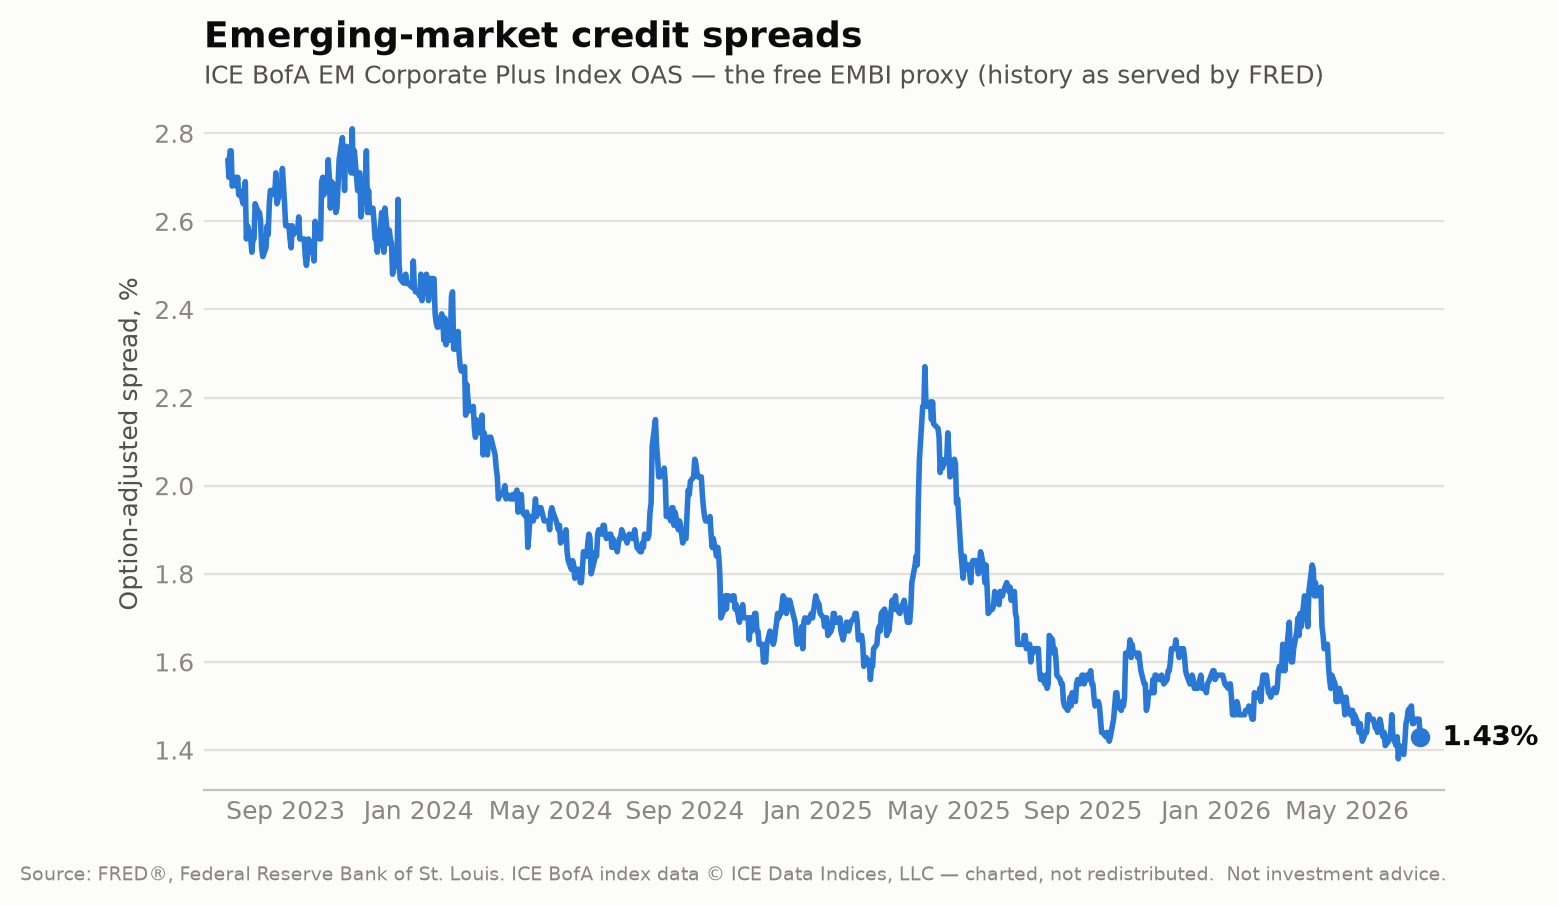

In [7]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

SURFACE, INK, INK_2 = "#fcfcfb", "#0b0b0b", "#52514e"
MUTED, GRID, AXIS, SERIES = "#898781", "#e1e0d9", "#c3c2b7", "#2a78d6"

oas = (
    observations[observations.series_id == "BAMLEMCBPIOAS"]
    .sort_values("date")
    .set_index("date")["value"]
)

figure, axes = plt.subplots(figsize=(8, 4.5), dpi=200, facecolor=SURFACE)
axes.set_facecolor(SURFACE)
axes.plot(oas.index, oas.values, color=SERIES, linewidth=2, solid_capstyle="round")
axes.plot(oas.index[-1], oas.iloc[-1], "o", color=SERIES, markersize=6)
axes.annotate(
    f"{oas.iloc[-1]:.2f}%",
    xy=(oas.index[-1], oas.iloc[-1]),
    xytext=(8, -3),
    textcoords="offset points",
    color=INK,
    fontsize=10,
    fontweight="bold",
)

axes.grid(axis="y", color=GRID, linewidth=0.8)
axes.set_axisbelow(True)
for side in ("top", "right", "left"):
    axes.spines[side].set_visible(False)
axes.spines["bottom"].set_color(AXIS)
axes.tick_params(colors=MUTED, labelsize=9, length=0)
axes.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes.set_ylabel("Option-adjusted spread, %", color=INK_2, fontsize=9)
axes.margins(x=0.02)

axes.set_title(
    "Emerging-market credit spreads",
    color=INK,
    fontsize=13,
    fontweight="bold",
    loc="left",
    pad=18,
)
axes.text(
    0,
    1.02,
    "ICE BofA EM Corporate Plus Index OAS — the free EMBI proxy (history as served by FRED)",
    transform=axes.transAxes,
    color=INK_2,
    fontsize=9,
)
figure.text(
    0.01,
    0.01,
    "Source: FRED\u00ae, Federal Reserve Bank of St. Louis. ICE BofA index data "
    "\u00a9 ICE Data Indices, LLC \u2014 charted, not redistributed.  "
    "Not investment advice.",
    color=MUTED,
    fontsize=7,
)

figure.savefig(
    PACK_DIRECTORY / "chart_of_week.png", bbox_inches="tight", facecolor=SURFACE
)
print(f"wrote {PACK_DIRECTORY / 'chart_of_week.png'}")
plt.show()

## Next steps (checklist steps 3–8)

Pack contents: `market_summary.csv`, `what_moved.csv`, `candidate_links.csv`,
`chart_of_week.png`. Copy `newsletter/TEMPLATE.md` to
`newsletter/issues/<ISSUE_DATE>.md`, fill it from the pack, verify every number,
and sign off before publishing. The disclaimer and attribution boilerplate is
template section 7 — ship it verbatim.